# Operating point and lock acquisition of Virgo 
Yashwant Bothra, 15.06.2026

This file is part of the hands-on session during the Finesse workshop at the ET Symposium in Aachen.

In this notebook we will bring a Dual-recycled Fabry-Perot Michelson9n Interferometer (DRFPMI) to the correct operating point and following the lock acquisition of the actual experiment. We will make use of `Actions` in FINESSE to achieve the locking of the interferometer. 

## Python imports and helpers

We use the following code block to load some extra packages and files into Google Colab if you are running this notebook there. The following cells load the Python libraries required by this notebook.

In [ ]:

# This code block is only needed on Google Colab, you don't need this
# when running the notebook locally, but it can be executed without 
# causing any problems.

# install pypi wheel only on google colab
!env | grep -q 'colab' && pip install finesse git+https://gitlab.com/ifosim/ifotools.git@dbb86e36512178b2e02096b8b54311bbfd1e282f || echo 'Not on google colab, assuming finesse already installed'

# transfer extra files from github repository 
import os, urllib.request
REPO = "https://raw.githubusercontent.com/gwoptics/finesse3_workshop/main"

def ensure(path):
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{REPO}/{path}", path)

# List all the files that the notebook expects to load
ASSETS = [
    'operating_point_files/Virgo_DRFPMI.kat',
    'operating_point_files/carm_offset.png',
    'operating_point_files/cavities.kat',
    'operating_point_files/detectors_rf.kat',
    'operating_point_files/dofs_locks.kat',
    'operating_point_files/readouts.kat',
    'operating_point_files/start_lock.png',
    'operating_point_files/variables.kat',
    'operating_point_files/virgo_model.png',
    ]

for f in ASSETS:
    ensure(f)

Not on google colab, assuming finesse already installed


In [2]:
from finesse import Model
from finesse.analysis.actions import (Xaxis, Change, Maximize, Minimize, Series,
                                      SensingMatrixDC, OptimiseRFReadoutPhaseDC,
                                      SetLockGains, GetErrorSignals, RunLocks) 
                                    

from ifotools.virgo.model_info import print_lengths_frequencies, print_model_state
from ifotools.finesse.plotting import plot_error_signals
from ifotools.finesse.model_info import print_tunings

import matplotlib.pyplot as plt

## AdV O4 design

<img src="operating_point_files/virgo_model.png" width="600"/>

In this notebook we will simulate an ideal interferometer (Virgo) model to bring it to the right operating point and lock the interferometer at the operating point. The following sequence is adopted for the lock-acquisition:

1. Bringing the arms to resonance for the IR
2. Creating CARM-offset to bring the IR out of resonance for the arm cavities
3. Locking the CITF: MICH, PRCL, and SRCL dofs (using 1f & 3f signals)
4. CARM-offset reduction
5. Locking CARM and DARM dof and steady state lock of all the dofs

In [3]:
# Advance Virgo model (Ideal)
# Initialising all the optics and detectors for the model
advi = Model()
advi.parse_file("operating_point_files/Virgo_DRFPMI.kat")
advi.parse_file("operating_point_files/cavities.kat")
advi.parse_file("operating_point_files/variables.kat")
advi.parse_file("operating_point_files/dofs_locks.kat")
advi.parse_file("operating_point_files/readouts.kat")
advi.parse_file("operating_point_files/detectors_rf.kat")
advi.modes(maxtem=4)

# Printing model state
print_lengths_frequencies(advi)
print_model_state(advi)

┌────────────────────────────────┬─────────────┐
│ Arm lengths                    │             │
│ lnarm                          │ 2999.8203 m │
│ lwarm                          │ 2999.7884 m │
│ Michelson & recycling cavities │             │
│ lpr                            │ 6.0516 m    │
│ ln                             │ 6.0166 m    │
│ lw                             │ 5.7867 m    │
│ lPRC                           │ 11.9533 m   │
│ lSRC                           │ 11.9526 m   │
│ lMI                            │ 5.9016 m    │
│ lSchnupp                       │ 0.2299 m    │
│ FSR                            │             │
│ fsrN                           │ 0.0500 MHz  │
│ fsrW                           │ 0.0500 MHz  │
│ fsrPRC                         │ 12.5402 MHz │
│ fsrSRC                         │ 12.5409 MHz │
│ Freq match                     │             │
│ f1_arm                         │ 6.2707 MHz  │
│ f1_SRC                         │ 0.1749 MHz  │
│ f1_PRC            

'\x1b\x1bDOFs          \x1b\x1b\x1bLocks         \x1b\x1b\x1bReadouts      \x1b\x1b\x1bCavities      \x1b\x1b\x1bMechanics     \x1b\x1b\x1bEtalon State    \x1b\x1b\x1bPhase Config    \x1b\x1b\x1bHOMs          \x1b\n\x1bYes           \x1b\x1bNo            \x1b\x1bYes           \x1b\x1bYes           \x1b\x1bNo            \x1b\x1bLinked          \x1b\x1bPhase 2         \x1b\x1bYes           \x1b\n'

## Local Control of the arms and creating a CARM-offset

Here we locally control the North and West end mirror to bring the arm cavities to resonance for the IR (main laser). The CARM and DARM dofs are not used at this stage of the lock acquisition.

Steps:
1. We misalign all the recycling mirrors, keeping only the arm cavity mirrors aligned.
2. After the misalignment we maximize the power transmitted while using the end mirror dof. 
3. After bringing the arm cavities in resonance for the IR, we create a known offset called the CARM-offset to bring the IR out of resonance in the arm cavities. At this point the arm cavities are controlled by the green laser (auxillary laser system). In our case we donot model the ALS.

<img src="operating_point_files/start_lock.png" width="600"/>


In [4]:
# Bringing the arms on resonance for the infrared (main laser beam)
arms_IR = advi.deepcopy()

arms_IR.run(Series(

    # Step 1: Misaligning the recycling mirrors keeping only the arm
    # cavity mirrors aligned
    Change({"PR.misaligned": True, "SR.misaligned": True}),

    # Step 2: Pretuning the optics bringing it to the operating point
    # Maximizing the power transmitted or resonance of main laser
    Maximize("B7_DC", "NE_z.DC", bounds=[-180, 180], tol=1e-14),
    Maximize("B8_DC", "WE_z.DC", bounds=[-180, 180], tol=1e-14)
));


In [5]:
print_tunings(arms_IR, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ WE    ║    2.783e-06 │   8.225e-06 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NE    ║    2.106e-06 │   6.224e-06 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ SR    ║            0 │           0 │         0 │ -SRCL.DC + SR_z.DC                     │
│ NI    ║            0 │           0 │         0 │ -MICH.DC + NI_z.DC                     │
│ PR    ║            0 │           0 │         0 │ PRCL.DC + PR_z.DC                      │
│ WI    ║            0 │           0 │         0 │ MICH.DC + WI_z.DC                      │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



### CARM-offset

In [6]:
## Creating a CARM-offset to bring the arms out of resonance for the IR
carm_offset = arms_IR.deepcopy()
run0 = carm_offset.run()

## Adding the CARM offset to the end mirrors
carm_offset.NE_z.DC += 10.8
carm_offset.WE_z.DC += 10.8

print_tunings(carm_offset, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ PR    ║            0 │           0 │         0 │ PRCL.DC + PR_z.DC                      │
│ NE    ║         10.8 │       31.92 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ SR    ║            0 │           0 │         0 │ -SRCL.DC + SR_z.DC                     │
│ NI    ║            0 │           0 │         0 │ -MICH.DC + NI_z.DC                     │
│ WI    ║            0 │           0 │         0 │ MICH.DC + WI_z.DC                      │
│ WE    ║         10.8 │       31.92 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



## CITF control of the interferometer

Now once this CARM-offset is completed, we have disentangled the CITF longitudinal dofs with the CARM and DARM dof. This makes the lock acquisition of the CITF easier. 

Steps to lock the CITF:
1. Pre-tuning the CITF to bring it to the right working point or close by.
2. Check figures of merits and error signals of the pre-tuning sequence.  
3. Locking the CITF dofs first using 1f signals and later using 3f to check if both the error signals work. 

<img src="operating_point_files/carm_offset.png" width="800"/>

In [7]:
# Building a new model for the CITF with the carm offset
citf = carm_offset.deepcopy()
print_model_state(citf) # checking the model state

# Aligning bacl the recycling mirrors
# At this point all the mirrors are aligned with the arms having
# a CARM-offset. 
citf.run(Change({"PR.misaligned": False, "SR.misaligned": False}))
run1 = citf.run()

DOFs          Locks         Readouts      Cavities      Mechanics     Etalon State    Phase Config    HOMs          
Yes           No            Yes           Yes           No            Linked          Phase 2         Yes           



In [8]:
# Tuning to bring the CITF dofs to the working point
citf_wp = citf.deepcopy()

# adding amplitude detectors for the optimization
citf_wp.parse(
    """
    ad b2adc B2_attenuator.p2.o f=l1.f n=0 m=0
    ad b4adc B4_attenuator.p2.o f=l1.f n=0 m=0
    ad b1padc SRAR.p2.o f=l1.f n=0 m=0
    """
)

# Pre-tuning the CITF dofs to the working point
citf_wp.run(Series(
    # Now we bring the CITF dofs to the right working point by optimizing
    # some of the signals which is used in the experiment (especially 2f signals)
    Minimize("b1padc", "MICH.DC", bounds=[-180,180], tol=1e-14), 
    Maximize("b4_12", "PRCL.DC", bounds=[-180,180], tol=1e-14),
    Maximize("b4_112", "SRCL.DC", bounds=[-180,180], tol=1e-14)
));

In [9]:
print_tunings(citf_wp, only_dof=True)

# after pre-tuning all the mirrors are tuned to satisfy the pre-tuning conditions

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ PR    ║      0.04175 │      0.1234 │         0 │ PRCL.DC + PR_z.DC                      │
│ WE    ║         10.8 │       31.91 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NE    ║         10.8 │       31.93 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ SR    ║         89.9 │       265.7 │         0 │ -SRCL.DC + SR_z.DC                     │
│ NI    ║     0.002081 │    0.006151 │         0 │ -MICH.DC + NI_z.DC                     │
│ WI    ║    -0.002081 │   -0.006151 │         0 │ MICH.DC + WI_z.DC                      │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



### Checking the figures of merit and the conditions that needs to be fulfilled after pre-tuning

These conditions in the actual experiment are set by the triggers. Here we look at those triggers to see if we are sitting at the right working point of the CITF where we can lock the optical system. 

In [10]:
# PRCL dof scan and figures of merit
sc_prcl = citf_wp.run(Xaxis("PRCL.DC", "lin", -100, 100, 200, relative=True))

# MICH dof scan and figures of merit
sc_mich = citf_wp.run(Xaxis("MICH.DC", "lin", -100, 100, 200, relative=True))

# SRCL dof scan and figures of merit
sc_srcl = citf_wp.run(Xaxis("SRCL.DC", "lin", -100, 100, 200, relative=True))

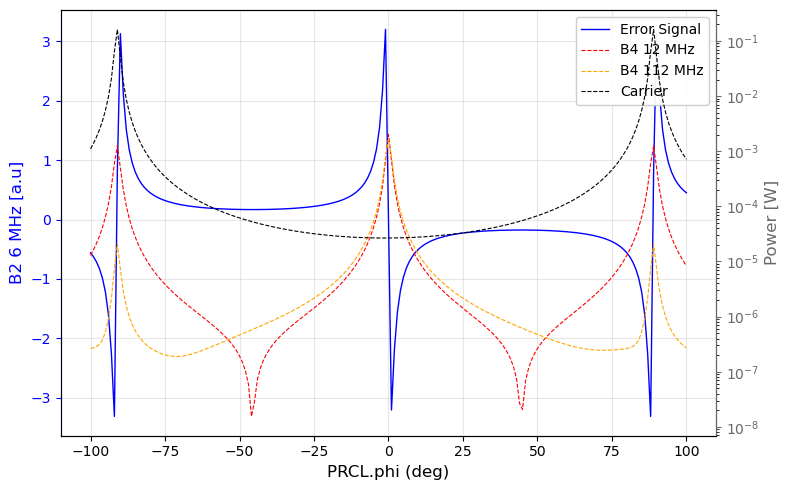

In [11]:
# Plot for the PRCL dof scans and checking the figures of merit
fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
ax.plot(sc_prcl.x[0], sc_prcl["B2_6_I"],       color='blue',  label="Error Signal",
        linewidth=1)
ax2.plot(sc_prcl.x[0], abs(sc_prcl["b4_12"]),  color='red',   label="B4 12 MHz",
         linestyle='--', linewidth=0.8)
ax2.plot(sc_prcl.x[0], abs(sc_prcl["b4_112"]), color='orange',label="B4 112 MHz",
         linestyle='--', linewidth=0.8)
ax2.plot(sc_prcl.x[0], abs(sc_prcl["b4adc"])**2, color='black',label="Carrier", 
         linestyle='--', linewidth=0.8)
ax2.set_yscale("log")
ax.set_xlabel(r"PRCL.phi (deg)", fontsize=12)
ax.set_ylabel(r"B2 6 MHz [a.u]", fontsize=12)
ax2.set_ylabel(r"Power [W]", fontsize=12)
ax.grid(True, which="both", alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, framealpha=0.95, loc="best")
ax.tick_params(labelsize=10)
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')
ax.spines['left'].set_color('blue')
ax2.yaxis.label.set_color('dimgray')
ax2.tick_params(axis='y', colors='dimgray')
ax2.spines['right'].set_color('dimgray')
plt.tight_layout()
plt.show()

Carrier is anti-resonant at the PRCL working point but the sidebands 6 and 56 MHz are both resonant in the PRC with the CARM-offset. Now the PRCL working point is confirmed well with the figure of merit as shown above.

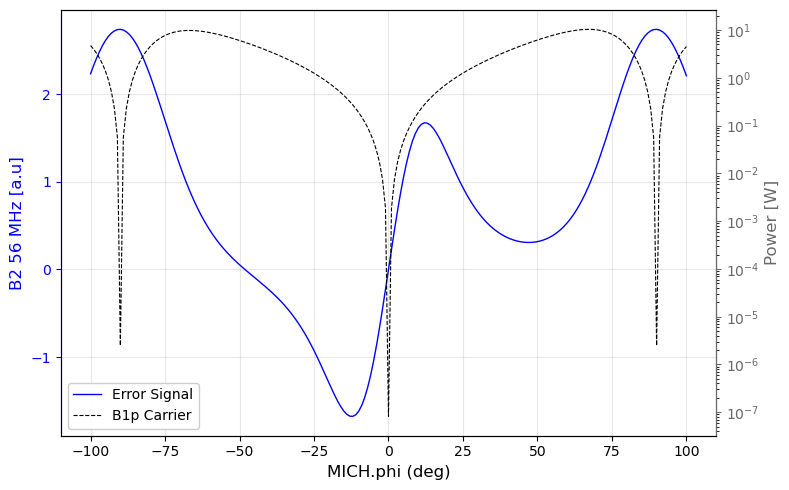

In [12]:
# Plot for the MICH dof scans and checking the figures of merit
fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
ax.plot(sc_mich.x[0], sc_mich["B2_56_I"],       color='blue',  label="Error Signal",
        linewidth=1)
ax2.plot(sc_mich.x[0], abs(sc_mich["b1padc"])**2, color='black',label="B1p Carrier", 
         linestyle='--', linewidth=0.8)
ax2.set_yscale("log")
ax.set_xlabel(r"MICH.phi (deg)", fontsize=12)
ax.set_ylabel(r"B2 56 MHz [a.u]", fontsize=12)
ax2.set_ylabel(r"Power [W]", fontsize=12)
ax.grid(True, which="both", alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, framealpha=0.95, loc="best")
ax.tick_params(labelsize=10)
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')
ax.spines['left'].set_color('blue')
ax2.yaxis.label.set_color('dimgray')
ax2.tick_params(axis='y', colors='dimgray')
ax2.spines['right'].set_color('dimgray')
plt.tight_layout()
plt.show()

The MICH working point should satisfy only one condition that the carrier is on dark-fringe. The MICH dof does not get effected once the CARM-offset is reduced. It is independent of the CARM offset. 

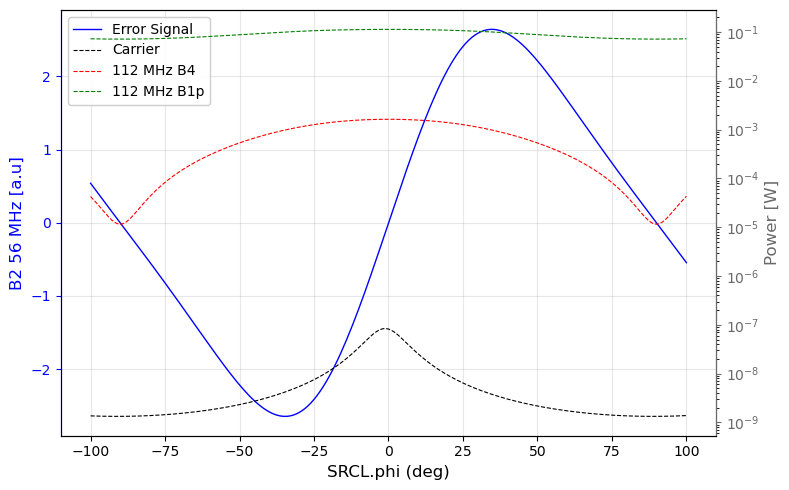

In [13]:
# Plot for the SRCL dof scans and checking the figures of merit
fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
ax.plot(sc_srcl.x[0], sc_srcl["B2_56_Q"],       color='blue',  label="Error Signal",
        linewidth=1)
ax2.plot(sc_srcl.x[0], abs(sc_srcl["b1padc"])**2, color='black',label="Carrier", 
         linestyle='--', linewidth=0.8)
ax2.plot(sc_srcl.x[0], abs(sc_srcl["b4_112"]), color='red',label="112 MHz B4", 
         linestyle='--', linewidth=0.8)
ax2.plot(sc_srcl.x[0], abs(sc_srcl["b1p_112"]), color='green',label="112 MHz B1p", 
         linestyle='--', linewidth=0.8)
ax2.set_yscale("log")
ax.set_xlabel(r"SRCL.phi (deg)", fontsize=12)
ax.set_ylabel(r"B2 56 MHz [a.u]", fontsize=12)
ax2.set_ylabel(r"Power [W]", fontsize=12)
ax.grid(True, which="both", alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, framealpha=0.95, loc="best")
ax.tick_params(labelsize=10)
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')
ax.spines['left'].set_color('blue')
ax2.yaxis.label.set_color('dimgray')
ax2.tick_params(axis='y', colors='dimgray')
ax2.spines['right'].set_color('dimgray')
plt.tight_layout()
plt.show()

The SRCL working point should satisfy the following conditions:
1. The 56 MHz sideband is resonant inside the PRC and SRC. 
2. The carrier is resonant inside the SRCL as after CARM-offset reduction the carrier becomes anti-resonant inside the SRC.

### Sensing Matrix & Optimization

Now we optimize the readouts for the 1f error signals which will be used for the initial lock of the CITF dofs.

In [14]:
# Sensing Matrix of our model
citf_tun = citf_wp.deepcopy()

# Sensing Matrix for the CITF dofs, Looking at 
# both 1f and 3f signals
sens_matrix_dc = citf_tun.run(SensingMatrixDC(['PRCL', 'MICH', 'SRCL'], 
                                              ['B2_6', 'B2_18', 'B2_56', 'B2_168']))
print(sens_matrix_dc)

┌──────╥────────┬─────────┬─────────┬──────────┬─────────┬─────────┬──────────┬──────────┐
│      ║ B2_6_I │ B2_6_Q  │ B2_18_I │ B2_18_Q  │ B2_56_I │ B2_56_Q │ B2_168_I │ B2_168_Q │
╞══════╬════════╪═════════╪═════════╪══════════╪═════════╪═════════╪══════════╪══════════╡
│ PRCL ║   -9.1 │     1.9 │   0.067 │   -0.033 │      -1 │     6.6 │   -0.052 │   -0.019 │
├──────╫────────┼─────────┼─────────┼──────────┼─────────┼─────────┼──────────┼──────────┤
│ MICH ║ -0.015 │   0.039 │  -4E-05 │ -0.00044 │    0.23 │   0.064 │   -0.001 │    0.002 │
├──────╫────────┼─────────┼─────────┼──────────┼─────────┼─────────┼──────────┼──────────┤
│ SRCL ║ -0.002 │ 0.00046 │ 4.1E-05 │ -2.6E-05 │  -0.018 │    0.12 │  -0.0015 │ -0.00057 │
└──────╨────────┴─────────┴─────────┴──────────┴─────────┴─────────┴──────────┴──────────┘



In [15]:
# Finalizing dof and its error signals

dof_pds = {'PRCL': 'B2_6_I', 'MICH': 'B2_56_I', 'SRCL': 'B2_56_2_Q'} 

## Optimizing the demodulation phases for the chosen error signals (1f)
## dof_pds is the chosen error signals for the locks
for dof in dof_pds.keys():
    citf_tun.run(OptimiseRFReadoutPhaseDC(dof, dof_pds[dof]))

# Sensing Matrix for the CITF dofs
sens_matrix_dc2 = citf_tun.run(SensingMatrixDC(['PRCL', 'MICH', 'SRCL'], 
                                               ['B2_6', 'B2_18', 'B2_56', 'B2_56_2', 'B2_168']))
print(sens_matrix_dc2)

print(f"Demodulation phase:{citf_tun.B2_6.phase.eval()} deg")
print(f"Demodulation phase:{citf_tun.B2_56.phase.eval()} deg")
print(f"Demodulation phase:{citf_tun.B2_56_2.phase.eval()} deg")

┌──────╥────────┬──────────┬─────────┬──────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┐
│      ║ B2_6_I │  B2_6_Q  │ B2_18_I │ B2_18_Q  │ B2_56_I │ B2_56_Q  │ B2_56_2_I │ B2_56_2_Q │ B2_168_I │ B2_168_Q │
╞══════╬════════╪══════════╪═════════╪══════════╪═════════╪══════════╪═══════════╪═══════════╪══════════╪══════════╡
│ PRCL ║    9.3 │  7.8E-05 │   0.067 │   -0.033 │    0.79 │      6.7 │     0.022 │      -6.7 │   -0.052 │   -0.019 │
├──────╫────────┼──────────┼─────────┼──────────┼─────────┼──────────┼───────────┼───────────┼──────────┼──────────┤
│ MICH ║  0.022 │   -0.036 │  -4E-05 │ -0.00044 │    0.24 │ -3.2E-05 │     -0.23 │    -0.029 │   -0.001 │    0.002 │
├──────╫────────┼──────────┼─────────┼──────────┼─────────┼──────────┼───────────┼───────────┼──────────┼──────────┤
│ SRCL ║ 0.0021 │ -3.2E-05 │ 4.1E-05 │ -2.6E-05 │   0.015 │     0.12 │   1.6E-05 │     -0.12 │  -0.0015 │ -0.00057 │
└──────╨────────┴──────────┴─────────┴──────────┴─────────┴─────

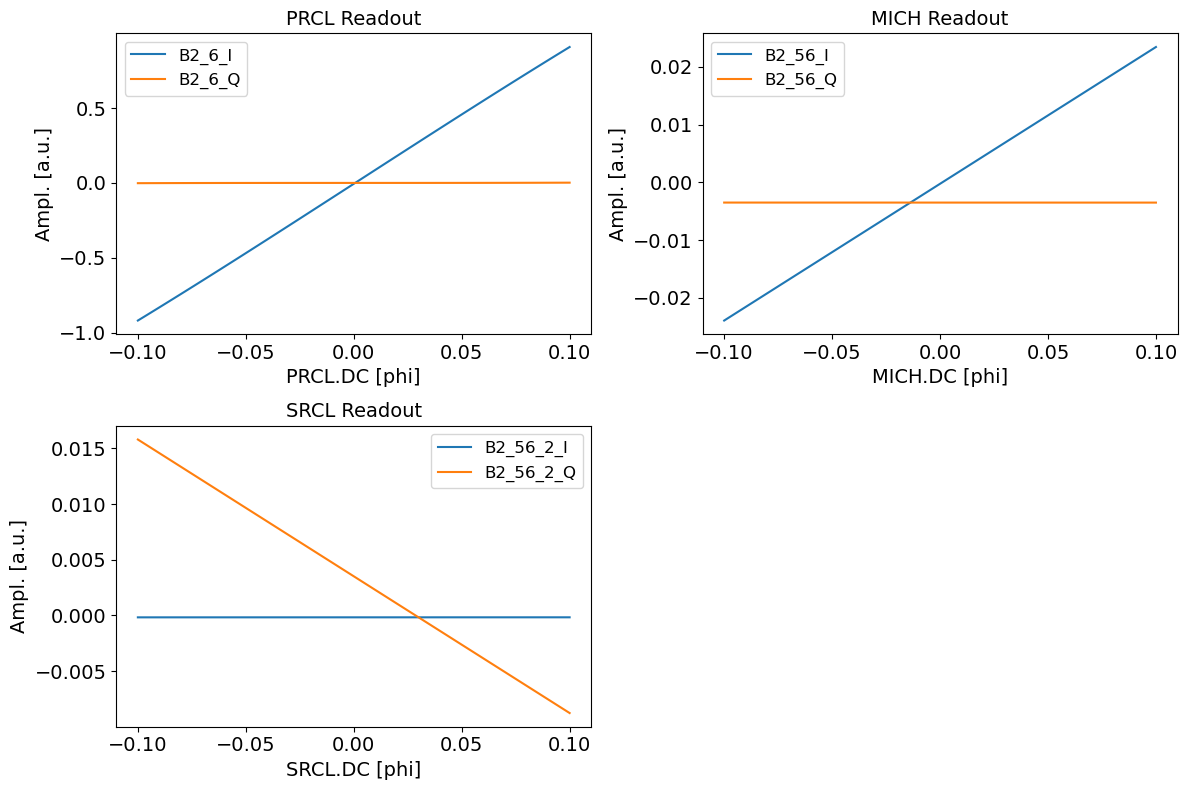

In [16]:
# Checking the error signals for the optimized demodulation
d_i = {"PRCL": "B2_6_I", "MICH": "B2_56_I", "SRCL": "B2_56_2_I"}
d_q = {"PRCL": "B2_6_Q", "MICH": "B2_56_Q", "SRCL": "B2_56_2_Q"}

plot_error_signals(citf_tun, dof_pds=d_i, dof_pds_q=d_q, x_min=-0.1, x_max=0.1, points=100)

In [17]:
print_tunings(citf_tun, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ WI    ║    -0.002081 │   -0.006151 │         0 │ MICH.DC + WI_z.DC                      │
│ PR    ║      0.04175 │      0.1234 │         0 │ PRCL.DC + PR_z.DC                      │
│ NE    ║         10.8 │       31.93 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ WE    ║         10.8 │       31.91 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NI    ║     0.002081 │    0.006151 │         0 │ -MICH.DC + NI_z.DC                     │
│ SR    ║         89.9 │       265.7 │         0 │ -SRCL.DC + SR_z.DC                     │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



### Locking (1f): 

Here we perform the initial lock of the CITF using 1f signals. Later we will lock the same dofs using 3f signals which are used in the experiment during the CARM-offset reduction.

In [18]:
## CITF Locking scheme
citf_lock = citf_tun.deepcopy()

# Defining the locks in our model 
# for the CITF lock acquisition (1f signals)
citf_lock.parse(
    """  
    # locks
    # TEMPLATE: lock pdh_lock pdh_err.outputs.I ITM_z.DC 0 1e-6 

    lock PRCL_lock B2_6.outputs.I PRCL.DC 0 1e-14
    lock MICH_lock B2_56.outputs.I MICH.DC 0 1e-14
    lock SRCL_lock B2_56_2.outputs.Q SRCL.DC 0 1e-14  
    """)

# Setting Lock gains
citf_lock.run(SetLockGains())

# Checking gains
print(citf_lock.MICH_lock.gain)
print(citf_lock.PRCL_lock.gain)
print(citf_lock.SRCL_lock.gain)

-4.224525938087939
-0.10751655412639616
8.14328872794704


In [19]:
# Locking the dofs with their respective sensors
errs_sig = citf_lock.run(GetErrorSignals("MICH_lock", "PRCL_lock", "SRCL_lock"))

print("Initial Error Signals:", errs_sig.results, end="\n\n")

# Running the locks
citf_lock.run(RunLocks(method='newton', display_progress=True, show_progress_bar=True))

Initial Error Signals: [-0.00025459 -0.00608721  0.00351394]



PRCL_lock ✗ MICH_lock ✗ SRCL_lock ✗ |##########| 10000/10000

Error Signal Residuals at Each Iteration (W):
                          PRCL_lock      MICH_lock      SRCL_lock   
                           B2_6_I1       B2_56_I1      B2_56_2_Q1   
Iteration Number    0     -6.09e-03      -2.55e-04       3.51e-03   
Iteration Number    1      8.29e-09       3.25e-09       1.89e-09   
Iteration Number    2      2.76e-14       2.15e-14      -7.67e-14   
Iteration Number    3      1.66e-14      -2.29e-15       9.55e-15   
Iteration Number    4     -6.18e-16      -1.70e-15      -5.28e-15   

<RunLocksSolution of run locks @ 0x17332b1d0 children=0>

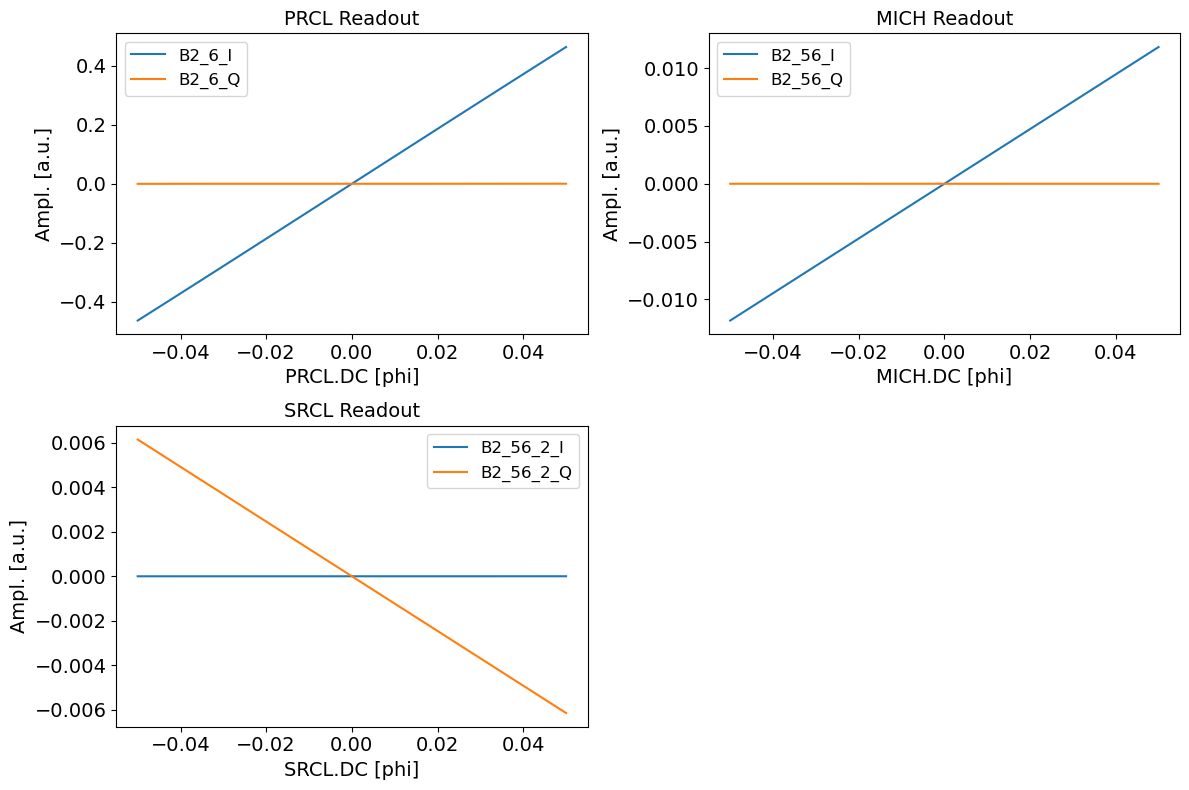

In [20]:
# Checking the error signals after the locks
d_i = {"PRCL": "B2_6_I", "MICH": "B2_56_I", "SRCL": "B2_56_2_I"}
d_q = {"PRCL": "B2_6_Q", "MICH": "B2_56_Q", "SRCL": "B2_56_2_Q"}

plot_error_signals(citf_lock, dof_pds=d_i, dof_pds_q=d_q, x_min=-0.05, x_max=0.05, points=100)

### Locking the CITF using 3f

In [21]:
# Locking the CITF with the 3f signals
citf_3f = citf_wp.deepcopy()

# Finalizing dof and its error signals
dof_pds = {'PRCL': 'B2_18_I', 'MICH': 'B2_168_I', 'SRCL': 'B2_168_2_Q'} 

## Optimizing the demodulation phases for the chosen error signals
## dof_pds is the chosen error signals for the locks
for dof in dof_pds.keys():
    citf_3f.run(OptimiseRFReadoutPhaseDC(dof, dof_pds[dof]))

# Sensing Matrix for the CITF dofs
sens_matrix_dc2 = citf_3f.run(SensingMatrixDC(['PRCL', 'MICH', 'SRCL'], 
                                               ['B2_6', 'B2_18', 'B2_56', 'B2_168', 'B2_168_2']))
print(sens_matrix_dc2)

print(f"Demodulation phase:{citf_3f.B2_18.phase.eval()} deg")
print(f"Demodulation phase:{citf_3f.B2_168.phase.eval()} deg")
print(f"Demodulation phase:{citf_3f.B2_168_2.phase.eval()} deg")

┌──────╥────────┬─────────┬─────────┬──────────┬─────────┬─────────┬──────────┬──────────┬────────────┬────────────┐
│      ║ B2_6_I │ B2_6_Q  │ B2_18_I │ B2_18_Q  │ B2_56_I │ B2_56_Q │ B2_168_I │ B2_168_Q │ B2_168_2_I │ B2_168_2_Q │
╞══════╬════════╪═════════╪═════════╪══════════╪═════════╪═════════╪══════════╪══════════╪════════════╪════════════╡
│ PRCL ║   -9.1 │     1.9 │   0.075 │  3.8E-07 │      -1 │     6.6 │   0.0068 │    0.055 │    -0.0014 │     -0.055 │
├──────╫────────┼─────────┼─────────┼──────────┼─────────┼─────────┼──────────┼──────────┼────────────┼────────────┤
│ MICH ║ -0.015 │   0.039 │ 0.00016 │ -0.00041 │    0.23 │   0.064 │   0.0022 │ -1.3E-07 │    -0.0022 │   -0.00022 │
├──────╫────────┼─────────┼─────────┼──────────┼─────────┼─────────┼──────────┼──────────┼────────────┼────────────┤
│ SRCL ║ -0.002 │ 0.00046 │ 4.9E-05 │ -5.1E-06 │  -0.018 │    0.12 │  0.00015 │   0.0016 │   -2.5E-09 │    -0.0016 │
└──────╨────────┴─────────┴─────────┴──────────┴─────────┴──────

In [22]:
## CITF Locking scheme
citf_3f.parse(
    """  
    # locks
    # TEMPLATE: lock pdh_3f pdh_err.outputs.I ITM_z.DC 0 1e-6 

    lock PRCL_3f B2_18.outputs.I PRCL.DC 0 1e-14
    lock MICH_3f B2_168.outputs.I MICH.DC 0 1e-14
    lock SRCL_3f B2_168_2.outputs.Q SRCL.DC 0 1e-14 
    """)

citf_3f.run(SetLockGains())

print(citf_3f.MICH_3f.gain)
print(citf_3f.PRCL_3f.gain)
print(citf_3f.SRCL_3f.gain)

# Locking the dofs with their respective sensors
# Few checks before running the locks
errs_sig = citf_3f.run(GetErrorSignals("MICH_3f", "PRCL_3f", "SRCL_3f"))

print("Initial Error Signals:", errs_sig.results, end="\n\n")

# Running the locks
citf_3f.run(RunLocks(method='newton', display_progress=True, show_progress_bar=True))

-453.1156517122247
-13.385138875241443
635.3493064619666
Initial Error Signals: [-5.31035644e-06 -5.15479040e-05  4.02332288e-05]



PRCL_3f ✗ MICH_3f ✗ SRCL_3f ✗ |##########| 10000/10000

Error Signal Residuals at Each Iteration (W):
                           PRCL_3f        MICH_3f        SRCL_3f    
                          B2_18_I1       B2_168_I1     B2_168_2_Q1  
Iteration Number    0     -5.15e-05      -5.31e-06       4.02e-05   
Iteration Number    1      6.84e-11      -7.24e-12      -3.92e-11   
Iteration Number    2     -1.28e-16       1.01e-16       1.61e-16   

<RunLocksSolution of run locks @ 0x173329fd0 children=0>

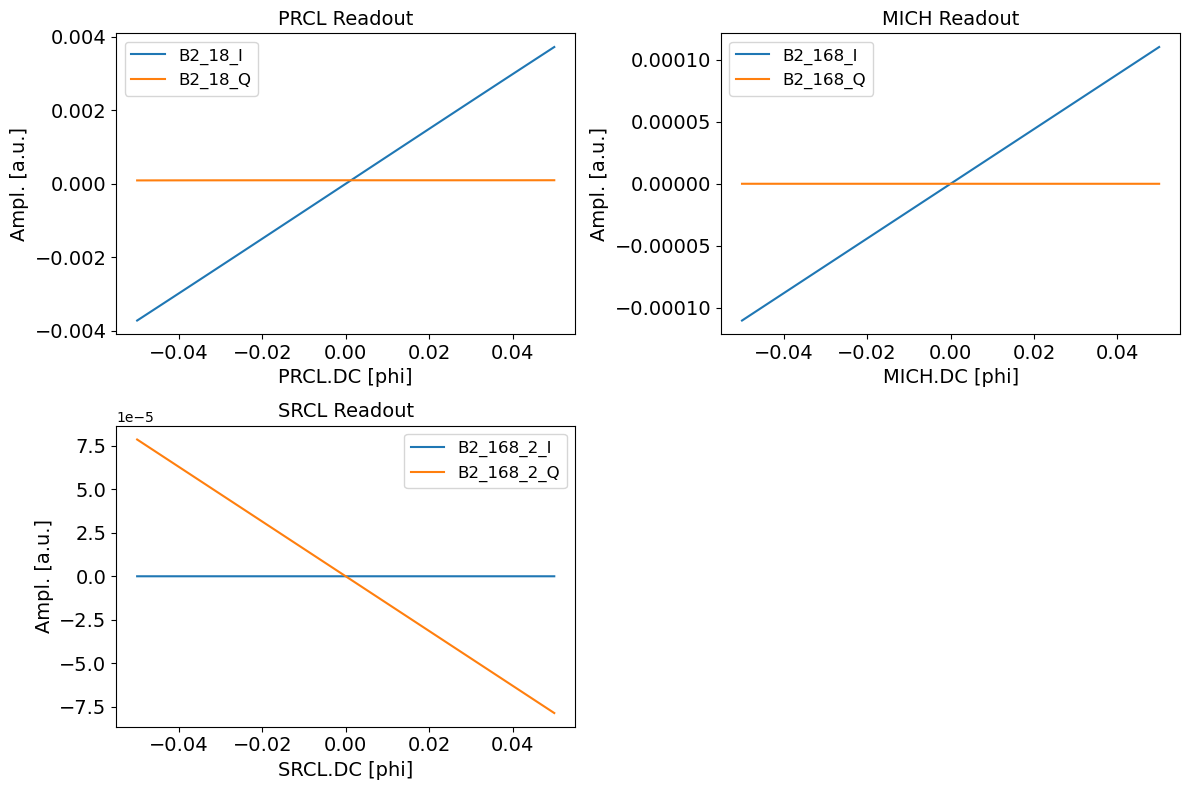

In [23]:
# Checking the error signals after the locks
d_i = {"PRCL": "B2_18_I", "MICH": "B2_168_I", "SRCL": "B2_168_2_I"}
d_q = {"PRCL": "B2_18_Q", "MICH": "B2_168_Q", "SRCL": "B2_168_2_Q"}

plot_error_signals(citf_3f, dof_pds=d_i, dof_pds_q=d_q, x_min=-0.05, x_max=0.05, points=100)

In [24]:
print_tunings(citf_3f, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ NE    ║         10.8 │       31.93 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ PR    ║      0.04244 │      0.1254 │         0 │ PRCL.DC + PR_z.DC                      │
│ SR    ║         89.9 │       265.7 │         0 │ -SRCL.DC + SR_z.DC                     │
│ WE    ║         10.8 │       31.91 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NI    ║     0.001889 │    0.005584 │         0 │ -MICH.DC + NI_z.DC                     │
│ WI    ║    -0.001889 │   -0.005584 │         0 │ MICH.DC + WI_z.DC                      │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



## CARM-offset Reduction

In [25]:
## Copying the model
citf_cor = citf_3f.deepcopy()

# checking the error signals before removing the CARM offset
errs_sig = citf_cor.run(GetErrorSignals("MICH_3f", "PRCL_3f", "SRCL_3f"))
print(f"Error signals before removing CARM offset: {errs_sig.results}")

# Removing the CARM offset to bring the arms back to resonance 
# for the main laser (IR) beam
print_model_state(citf_cor, verbose=True)

Error signals before removing CARM offset: [ 1.00817072e-16 -1.27807107e-16  1.60820126e-16]
DOFs          Locks         Readouts      Cavities      Mechanics     Etalon State    Phase Config    HOMs          
Yes           Yes           Yes           Yes           No            Linked          Phase 2         Yes           
┌──────────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Item         │ Count  │ Details                                                                                                                                                                                                                         │
╞══════════════╪════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

"\x1b\x1bDOFs          \x1b\x1b\x1bLocks         \x1b\x1b\x1bReadouts      \x1b\x1b\x1bCavities      \x1b\x1b\x1bMechanics     \x1b\x1b\x1bEtalon State    \x1b\x1b\x1bPhase Config    \x1b\x1b\x1bHOMs          \x1b\n\x1bYes           \x1b\x1bYes           \x1b\x1bYes           \x1b\x1bYes           \x1b\x1bNo            \x1b\x1bLinked          \x1b\x1bPhase 2         \x1b\x1bYes           \x1b\n┌──────────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐\n│ Item         │ Count  │ Details                                                                                                                                                                                                                         │\n╞══════════════╪════════╪════════════════════════════════════════════════════════════════════════

In [26]:
print_tunings(citf_cor, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ WE    ║         10.8 │       31.91 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NI    ║     0.001889 │    0.005584 │         0 │ -MICH.DC + NI_z.DC                     │
│ SR    ║         89.9 │       265.7 │         0 │ -SRCL.DC + SR_z.DC                     │
│ WI    ║    -0.001889 │   -0.005584 │         0 │ MICH.DC + WI_z.DC                      │
│ NE    ║         10.8 │       31.93 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ PR    ║      0.04244 │      0.1254 │         0 │ PRCL.DC + PR_z.DC                      │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



In [27]:
# CARM offset reduction. This offset was added to the
# individual mirror dofs. Now after tuning the IFO to the right OP
# we can remove the CARM offset and lock the CARM and DARM dofs.
citf_cor.NE_z.DC -= 10.8
citf_cor.WE_z.DC -= 10.8
citf_cor.run()

# checking the error signals before removing the CARM offset
errs_sig = citf_cor.run(GetErrorSignals("MICH_3f", "PRCL_3f", "SRCL_3f"))
print(f"Error signals after removing CARM offset: {errs_sig.results}")

Error signals after removing CARM offset: [ 0.00065056  0.00263126 -0.00177856]


In [28]:
# The error signals have moved, now RunLocks again on 3f
# Running the locks
citf_cor.run(RunLocks(method='newton', display_progress=True, show_progress_bar=True))

PRCL_3f ✗ MICH_3f ✗ SRCL_3f ✗ |##########| 10000/10000

Error Signal Residuals at Each Iteration (W):
                           PRCL_3f        MICH_3f        SRCL_3f    
                          B2_18_I1       B2_168_I1     B2_168_2_Q1  
Iteration Number    0      2.63e-03       6.51e-04      -1.78e-03   
Iteration Number    1     -1.74e-05      -6.84e-06       1.58e-06   
Iteration Number    2      1.54e-07      -4.51e-08       1.98e-07   
Iteration Number    3     -1.22e-09       3.49e-09      -4.91e-09   
Iteration Number    4      7.54e-12      -8.36e-11       8.12e-11   
Iteration Number    5     -1.49e-14       1.44e-12      -1.07e-12   
Iteration Number    6     -7.98e-16      -2.02e-14       1.10e-14   
Iteration Number    7     -7.33e-17       1.24e-17      -3.17e-16   

<RunLocksSolution of run locks @ 0x1735d6ce0 children=0>

In [29]:
print_tunings(citf_cor, only_dof=True)

┌───────╥──────────────┬─────────────┬───────────┬────────────────────────────────────────┐
│ optic ║ tuning [deg] │ tuning [nm] │ phi [deg] │ Symbolic                               │
╞═══════╬══════════════╪═════════════╪═══════════╪════════════════════════════════════════╡
│ WE    ║     0.007383 │     0.02182 │         0 │ CARM.DC + DARM.DC + MICH.DC + WE_z.DC  │
│ NI    ║     -0.00738 │    -0.02181 │         0 │ -MICH.DC + NI_z.DC                     │
│ SR    ║        89.33 │         264 │         0 │ -SRCL.DC + SR_z.DC                     │
│ WI    ║      0.00738 │     0.02181 │         0 │ MICH.DC + WI_z.DC                      │
│ NE    ║    -0.007378 │    -0.02181 │         0 │ -DARM.DC - MICH.DC + CARM.DC + NE_z.DC │
│ PR    ║    -0.003275 │    -0.00968 │         0 │ PRCL.DC + PR_z.DC                      │
└───────╨──────────────┴─────────────┴───────────┴────────────────────────────────────────┘



## Final Lock of the interferometer (Low Noise State)

Where all the controls are handed off to 1f signals along with CARM and DARM. At this point all the dofs should be at the right operating point. 

In [30]:
# Low Noise (State)
ifo_cd = citf_cor.deepcopy()

# Checking the sensing matrix of the ifo
sens_matrix_dc = ifo_cd.run(SensingMatrixDC(['PRCL', 'MICH', 'SRCL', 'CARM', 'DARM'], 
                                               ['B2_8', 'B4_6', 'B2_56', 'B2_56_2', 'B1p_56']))
print(sens_matrix_dc)

┌──────╥──────────┬─────────┬──────────┬──────────┬─────────┬─────────┬───────────┬───────────┬──────────┬──────────┐
│      ║  B2_8_I  │ B2_8_Q  │  B4_6_I  │  B4_6_Q  │ B2_56_I │ B2_56_Q │ B2_56_2_I │ B2_56_2_Q │ B1p_56_I │ B1p_56_Q │
╞══════╬══════════╪═════════╪══════════╪══════════╪═════════╪═════════╪═══════════╪═══════════╪══════════╪══════════╡
│ PRCL ║        6 │   -0.47 │  0.00095 │  -0.0026 │       1 │     1.1 │         1 │       1.1 │   0.0039 │  4.3E-05 │
├──────╫──────────┼─────────┼──────────┼──────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┤
│ MICH ║    0.014 │ -0.0011 │ -2.7E-05 │ -0.00019 │    -0.2 │  -0.036 │      -0.2 │    -0.036 │     0.23 │     0.17 │
├──────╫──────────┼─────────┼──────────┼──────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┤
│ SRCL ║  -0.0041 │ 0.00032 │  4.3E-05 │ -5.4E-06 │   0.018 │   -0.11 │     0.018 │     -0.11 │  -0.0002 │  0.00035 │
├──────╫──────────┼─────────┼──────────┼──────────┼─────

In [31]:
## Optimizing the demodulation phases for the chosen error signals
## dof_pds is the chosen error signals for the locks
dof_pds = {'PRCL': 'B2_8_I', 'MICH': 'B2_56_I', 'SRCL': 'B2_56_2_Q', 
           'CARM': "B4_6_I", "DARM": "B1p_56_I"}

for dof in dof_pds.keys():
    ifo_cd.run(OptimiseRFReadoutPhaseDC(dof, dof_pds[dof]))

# Sensing Matrix after the optimization
sens_matrix_dc2 = ifo_cd.run(SensingMatrixDC(['PRCL', 'MICH', 'SRCL', 'CARM', 'DARM'], 
                                               ['B2_8', 'B4_6', 'B2_56', 'B2_56_2', 'B1p_56']))
print(sens_matrix_dc2)

┌──────╥──────────┬─────────┬──────────┬──────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┐
│      ║  B2_8_I  │ B2_8_Q  │  B4_6_I  │  B4_6_Q  │ B2_56_I │ B2_56_Q  │ B2_56_2_I │ B2_56_2_Q │ B1p_56_I │ B1p_56_Q │
╞══════╬══════════╪═════════╪══════════╪══════════╪═════════╪══════════╪═══════════╪═══════════╪══════════╪══════════╡
│ PRCL ║        6 │ 1.4E-06 │   0.0012 │  -0.0025 │    -1.2 │    -0.94 │       1.2 │      0.97 │   0.0032 │  -0.0023 │
├──────╫──────────┼─────────┼──────────┼──────────┼─────────┼──────────┼───────────┼───────────┼──────────┼──────────┤
│ MICH ║    0.014 │ 2.5E-05 │ -6.2E-06 │ -0.00019 │    0.21 │ -0.00099 │     -0.21 │   -0.0033 │     0.28 │ -0.00031 │
├──────╫──────────┼─────────┼──────────┼──────────┼─────────┼──────────┼───────────┼───────────┼──────────┼──────────┤
│ SRCL ║  -0.0041 │ 1.4E-07 │  4.3E-05 │ -7.2E-07 │  0.0024 │     0.11 │   1.6E-05 │     -0.11 │  4.3E-05 │   0.0004 │
├──────╫──────────┼─────────┼──────────┼────────

In [32]:
# Locking the interferometer 
ifo = ifo_cd.deepcopy()

# Removing the previous locks 
ifo.remove("MICH_3f")
ifo.remove("PRCL_3f")
ifo.remove("SRCL_3f")

print_model_state(ifo, verbose=True)

DOFs          Locks         Readouts      Cavities      Mechanics     Etalon State    Phase Config    HOMs          
Yes           No            Yes           Yes           No            Linked          Phase 2         Yes           
┌──────────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Item         │ Count  │ Details                                                                                                                                                                                                                         │
╞══════════════╪════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ DOFs    

"\x1b\x1bDOFs          \x1b\x1b\x1bLocks         \x1b\x1b\x1bReadouts      \x1b\x1b\x1bCavities      \x1b\x1b\x1bMechanics     \x1b\x1b\x1bEtalon State    \x1b\x1b\x1bPhase Config    \x1b\x1b\x1bHOMs          \x1b\n\x1bYes           \x1b\x1bNo            \x1b\x1bYes           \x1b\x1bYes           \x1b\x1bNo            \x1b\x1bLinked          \x1b\x1bPhase 2         \x1b\x1bYes           \x1b\n┌──────────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐\n│ Item         │ Count  │ Details                                                                                                                                                                                                                         │\n╞══════════════╪════════╪════════════════════════════════════════════════════════════════════════

In [33]:
# Adding new locks
ifo.parse(
    """  
    # locks
    lock PRCL_lock B2_8.outputs.I PRCL.DC 0 1e-14
    lock MICH_lock B2_56.outputs.I MICH.DC 0 1e-14
    lock SRCL_lock B2_56_2.outputs.Q SRCL.DC 0 1e-14 
    lock CARM_lock B4_6.outputs.I CARM.DC 0 1e-14
    lock DARM_lock B1p_56.outputs.I DARM.DC 0 1e-14
    """)

# Setting gains for the locks
ifo.run(SetLockGains())
print(ifo.MICH_lock.gain)
print(ifo.PRCL_lock.gain)
print(ifo.SRCL_lock.gain)
print(ifo.CARM_lock.gain)
print(ifo.DARM_lock.gain)   

# Locking the dofs with their respective sensors
errs_sig = ifo.run(GetErrorSignals("PRCL_lock", "MICH_lock", "SRCL_lock", "CARM_lock", "DARM_lock"))

print("Initial Error Signals:", errs_sig.results, end="\n\n")

# Running the locks
ifo.run(RunLocks(method='newton', display_progress=True, show_progress_bar=True))

-4.831167504112836
-0.16612760682218658
8.732560235339562
-0.07360305581443076
-0.012451585952760483
Initial Error Signals: [-4.37438241e-02  1.21742821e-02 -8.17802236e-02  5.40677602e-06
  4.46113077e-03]



PRCL_lock ✗ MICH_lock ✗ SRCL_lock ✗ CARM_lock ✗ DARM_lock ✗ |##########| 10000/10000

Error Signal Residuals at Each Iteration (W):
                          PRCL_lock      MICH_lock      SRCL_lock      CARM_lock      DARM_lock   
                           B2_8_I1       B2_56_I1      B2_56_2_Q1       B4_6_I1       B1p_56_I1   
Iteration Number    0     -4.37e-02       1.22e-02      -8.18e-02       5.41e-06       4.46e-03   
Iteration Number    1      9.04e-06       4.19e-06       3.06e-05      -1.72e-08      -1.06e-05   
Iteration Number    2      3.13e-09       1.46e-08      -8.51e-09      -3.08e-11       7.75e-09   
Iteration Number    3     -3.29e-12       3.66e-11       4.77e-12       4.39e-14      -4.62e-12   
Iteration Number    4      4.65e-15       9.73e-14       2.13e-14       4.60e-17      -3.32e-16   
Iteration Number    5      1.31e-15      -1.36e-14       5.67e-15      -8.74e-17       2.12e-15   
Iteration Number    6     -1.26e-15       2.30e-14      -3.99e-14       4.44e-17      -7.63e-16   
Iteration Number    7     -4.61e-16      -8.89e-15       1.91e-

<RunLocksSolution of run locks @ 0x3122f5190 children=0>

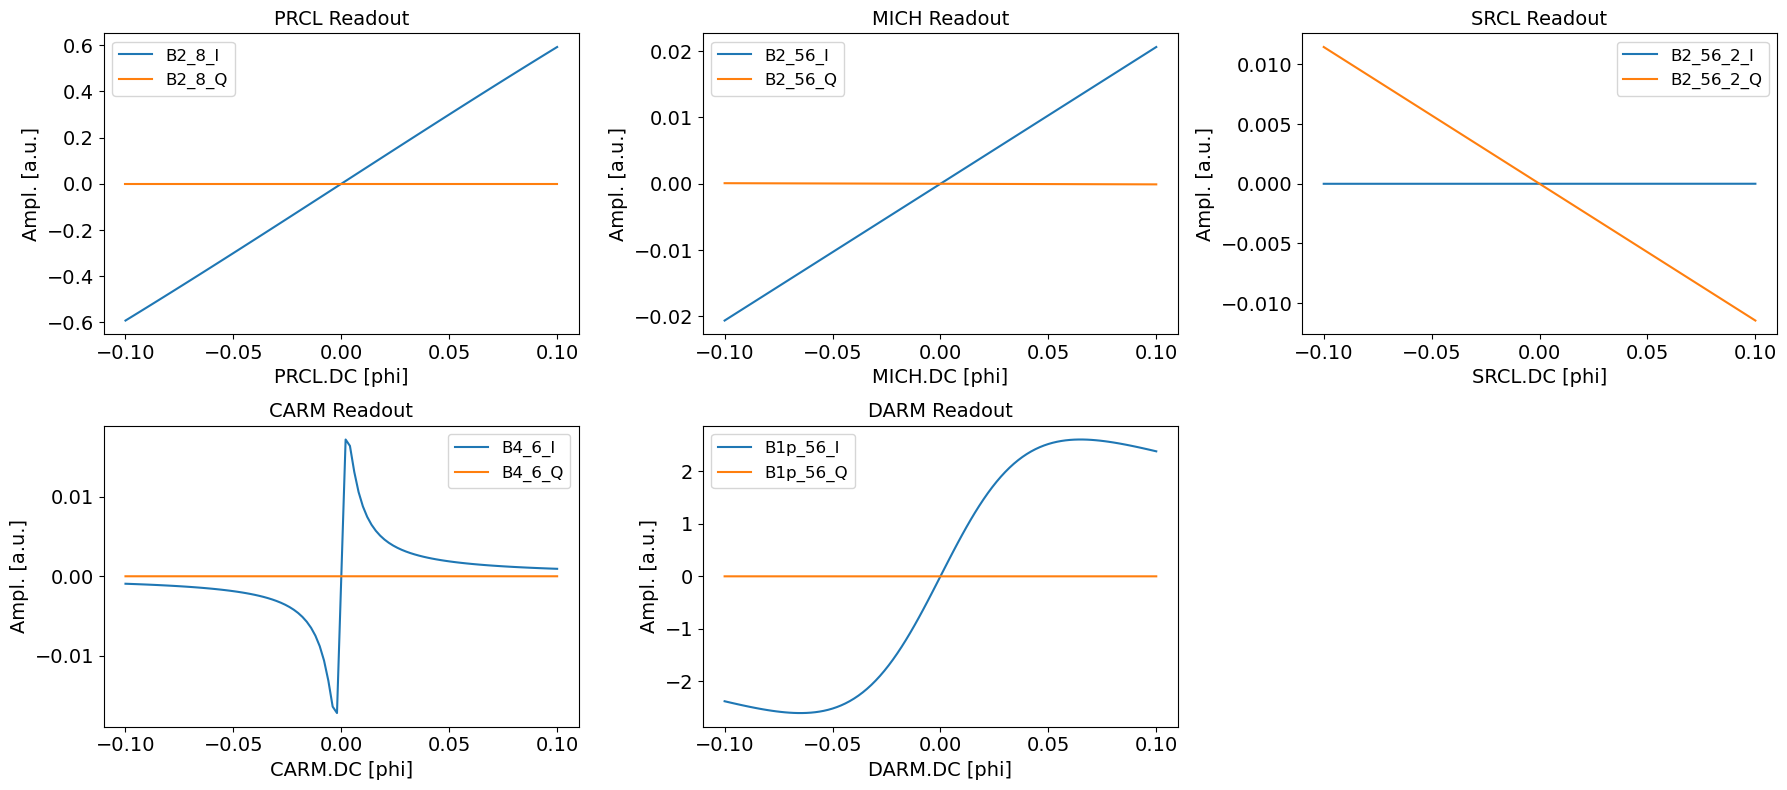

In [34]:
# Checking the error signals after the locks
d_i = {"PRCL": "B2_8_I", "MICH": "B2_56_I", "SRCL": "B2_56_2_I", "CARM": "B4_6_I", "DARM": "B1p_56_I"}
d_q = {"PRCL": "B2_8_Q", "MICH": "B2_56_Q", "SRCL": "B2_56_2_Q", "CARM": "B4_6_Q", "DARM": "B1p_56_Q"}

plot_error_signals(ifo, dof_pds=d_i, dof_pds_q=d_q, x_min=-0.1, x_max=0.1, points=100)